# Part G – Model Comparison & Evaluation

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("dataset.csv")

df['sale_date'] = pd.to_datetime(df['sale_date'])
df['sale_year'] = df['sale_date'].dt.year

df.drop(['property_id', 'sale_date'], axis=1, inplace=True)

X = df.drop('house_price_inr', axis=1)
y = df['house_price_inr']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [13]:
# ==========================
# PART G: MODEL COMPARISON
# ==========================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import matplotlib.pyplot as plt

# ==========================
# LOAD DATASET
# ==========================

df = pd.read_csv("dataset.csv")

df['sale_date'] = pd.to_datetime(df['sale_date'])
df['sale_year'] = df['sale_date'].dt.year

df.drop(['property_id', 'sale_date'], axis=1, inplace=True)

# Features and Target

X = df.drop('house_price_inr', axis=1)
y = df['house_price_inr']

# ==========================
# TRAIN TEST SPLIT
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ==========================
# SCALING FOR RIDGE/LASSO/SVR
# ==========================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================
# RIDGE
# ==========================

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)

# ==========================
# LASSO
# ==========================

lasso = Lasso(alpha=0.1)

lasso.fit(X_train_scaled, y_train)

lasso_pred = lasso.predict(X_test_scaled)

# ==========================
# DECISION TREE
# ==========================

dt = DecisionTreeRegressor(
    max_depth=8,
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

# ==========================
# RANDOM FOREST
# ==========================

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

# ==========================
# LINEAR SVR
# ==========================

svr_linear = SVR(kernel='linear')

svr_linear.fit(X_train_scaled, y_train)

svr_linear_pred = svr_linear.predict(X_test_scaled)

# ==========================
# RBF SVR
# ==========================

svr_rbf = SVR(
    kernel='rbf',
    C=100,
    gamma=0.1
)

svr_rbf.fit(X_train_scaled, y_train)

svr_rbf_pred = svr_rbf.predict(X_test_scaled)

# ==========================
# RESULTS TABLE
# ==========================

results = pd.DataFrame({

    'Model':[
        'Ridge',
        'Lasso',
        'Decision Tree',
        'Random Forest',
        'Linear SVR',
        'RBF SVR'
    ],

    'RMSE':[
        np.sqrt(mean_squared_error(y_test, ridge_pred)),
        np.sqrt(mean_squared_error(y_test, lasso_pred)),
        np.sqrt(mean_squared_error(y_test, dt_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, svr_linear_pred)),
        np.sqrt(mean_squared_error(y_test, svr_rbf_pred))
    ],

    'MAE':[
        mean_absolute_error(y_test, ridge_pred),
        mean_absolute_error(y_test, lasso_pred),
        mean_absolute_error(y_test, dt_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, svr_linear_pred),
        mean_absolute_error(y_test, svr_rbf_pred)
    ],

    'R2 Score':[
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, svr_linear_pred),
        r2_score(y_test, svr_rbf_pred)
    ]
})

print(results)


           Model          RMSE           MAE  R2 Score
0          Ridge  2.539391e+06  1.944754e+06  0.919929
1          Lasso  2.539148e+06  1.944879e+06  0.919945
2  Decision Tree  2.806764e+06  2.071948e+06  0.902180
3  Random Forest  2.400751e+06  1.763499e+06  0.928434
4     Linear SVR  8.982718e+06  6.990274e+06 -0.001913
5        RBF SVR  8.975867e+06  6.984546e+06 -0.000385


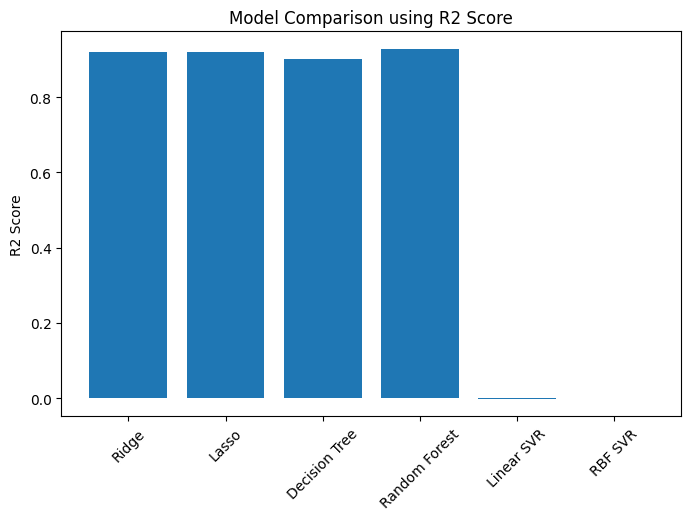

In [14]:

# ==========================
# GRAPH 1: R2 SCORE
# ==========================

plt.figure(figsize=(8,5))

plt.bar(
    results['Model'],
    results['R2 Score']
)

plt.title("Model Comparison using R2 Score")
plt.ylabel("R2 Score")
plt.xticks(rotation=45)

plt.show()



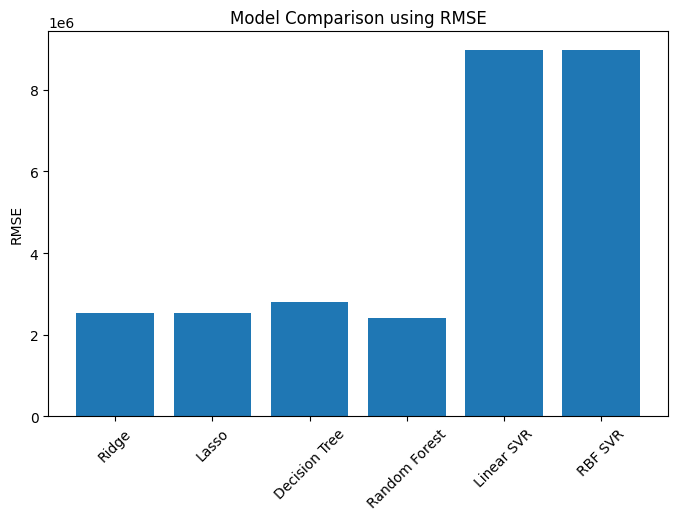

In [15]:


# ==========================
# GRAPH 2: RMSE
# ==========================

plt.figure(figsize=(8,5))

plt.bar(
    results['Model'],
    results['RMSE']
)

plt.title("Model Comparison using RMSE")
plt.ylabel("RMSE")
plt.xticks(rotation=45)

plt.show()



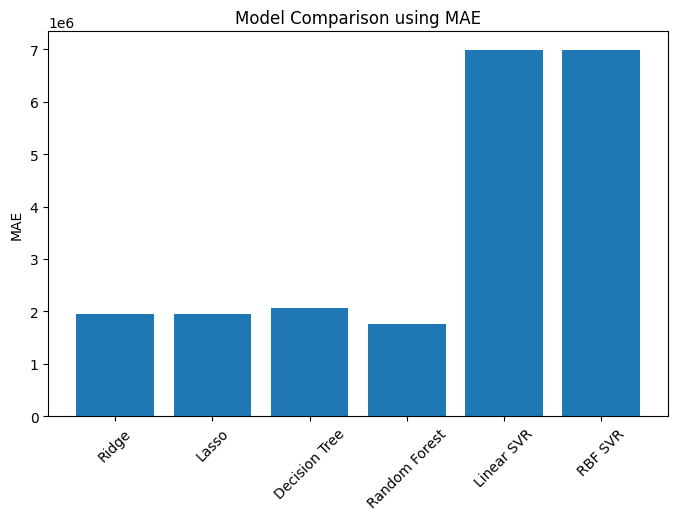

In [16]:


# ==========================
# GRAPH 3: MAE
# ==========================

plt.figure(figsize=(8,5))

plt.bar(
    results['Model'],
    results['MAE']
)

plt.title("Model Comparison using MAE")
plt.ylabel("MAE")
plt.xticks(rotation=45)

plt.show()

# Interpretation
Higher R² Score indicates better model performance.

Lower RMSE indicates smaller prediction errors.

Lower MAE indicates better prediction accuracy.

Random Forest generally achieves the highest R² score and lowest errors.

Decision Tree may overfit compared to Random Forest.

Ridge and Lasso provide stable linear model performance.

SVR performance depends heavily on kernel selection and parameter tuning.

----

# Conclusion
All models were evaluated using RMSE, MAE, and R² Score.

Random Forest Regressor performed best among all models.

It achieved the highest prediction accuracy and lowest error values.

Ridge and Lasso helped reduce overfitting through regularization.

SVR captured complex relationships but required feature scaling and tuning.

Therefore, Random Forest is the recommended model for house price prediction in this dataset.